# Examen - Introduction en IA
## Master Finance Digitale - FinTech Africa
### Pipeline de prétraitement pour la prédiction de défaut de paiement

## Importation des librairies

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

## Importation des données

In [75]:
df = pd.read_csv('/content/drive/MyDrive/AI_EXAMEN_FINAL/fintech4africa_dataset.csv')

In [76]:
df.head()

,client_id,age,revenu_mensuel,score_credit,historique_defaut,montant_transaction,type_compte,frequence_mobile_money,pays,niveau_risque,retard_paiement,nombre_prets,anciennete_client,defaut_paiement
0,C0272,50,60365.0,437.0,1,5166.0,Mobile Money,22,Togo,Très Élevé,1.0,9,12.0,1
1,C0207,27,227426.0,525.0,2,26261.0,Courant,20,Côte d'Ivoire,Élevé,0.0,3,9.0,1
2,C0424,33,134205.0,478.0,0,16182.0,Épargne,21,Sénégal,Élevé,0.0,2,4.0,1
3,C0342,19,368789.0,734.0,0,127292.0,Mobile Money,6,Burkina Faso,Faible,0.0,2,115.0,0
4,C0001,58,428393.0,737.0,0,63434.0,Courant,7,NaN,Faible,0.0,3,35.0,0


In [77]:
df.dtypes

,0
client_id,object
age,int64
revenu_mensuel,float64
score_credit,float64
historique_defaut,int64
montant_transaction,float64
type_compte,object
frequence_mobile_money,int64
pays,object
niveau_risque,object


---
## Question 1 : Rapport d'Audit Complet

### 1.1 - Dimension des données

In [78]:
df.shape
n = df.shape[0]
p = df.shape[1]
print('Nombre de clients :', n)
print('Nombre de variables :', p)

Nombre de clients : 505
Nombre de variables : 14


### 1.2 - Valeurs manquantes par colonne

In [79]:
# Nombre exact de valeurs manquantes par colonne
valeurs_manquantes = df.isnull().sum()
print(valeurs_manquantes)

client_id                  0
age                        0
revenu_mensuel            45
score_credit              56
historique_defaut          0
montant_transaction       35
type_compte               30
frequence_mobile_money     0
pays                      21
niveau_risque             15
retard_paiement           25
nombre_prets               0
anciennete_client         21
defaut_paiement            0
dtype: int64


In [80]:
# Pourcentage de valeurs manquantes par colonne
pourcentage_manquantes = (df.isnull().sum() / n) * 100
print(pourcentage_manquantes)

client_id                  0.000000
age                        0.000000
revenu_mensuel             8.910891
score_credit              11.089109
historique_defaut          0.000000
montant_transaction        6.930693
type_compte                5.940594
frequence_mobile_money     0.000000
pays                       4.158416
niveau_risque              2.970297
retard_paiement            4.950495
nombre_prets               0.000000
anciennete_client          4.158416
defaut_paiement            0.000000
dtype: float64


In [81]:
# Tableau récapitulatif clair de l'audit
audit = pd.DataFrame({
    'Valeurs_manquantes': df.isnull().sum(),
    'Pourcentage (%)': (df.isnull().sum() / n * 100).round(2),
    'Type': df.dtypes
})
print(audit)

                        Valeurs_manquantes  Pourcentage (%)     Type
client_id                                0             0.00   object
age                                      0             0.00    int64
revenu_mensuel                          45             8.91  float64
score_credit                            56            11.09  float64
historique_defaut                        0             0.00    int64
montant_transaction                     35             6.93  float64
type_compte                             30             5.94   object
frequence_mobile_money                   0             0.00    int64
pays                                    21             4.16   object
niveau_risque                           15             2.97   object
retard_paiement                         25             4.95  float64
nombre_prets                             0             0.00    int64
anciennete_client                       21             4.16  float64
defaut_paiement                   

### 1.3 - Détection des doublons

In [82]:
# Gestion des valeurs dupliquées
nb_doublons = df.duplicated().sum()
print('Nombre de doublons :', nb_doublons)

# Suppression des doublons
df = df.drop_duplicates()
print('Nouvelle taille après suppression des doublons :', df.shape)

Nombre de doublons : 5
Nouvelle taille après suppression des doublons : (500, 14)


### 1.4 - Types de données incohérents

In [83]:
# Type de variables
df.dtypes

# Correction : client_id doit être une catégorie, defaut_paiement un booléen
df['client_id'] = df['client_id'].astype('category')
df['defaut_paiement'] = df['defaut_paiement'].astype('boolean')

# Vérification
df.dtypes

,0
client_id,category
age,int64
revenu_mensuel,float64
score_credit,float64
historique_defaut,int64
montant_transaction,float64
type_compte,object
frequence_mobile_money,int64
pays,object
niveau_risque,object


In [84]:
# Description statistique des variables quantitatives
df.describe()

,age,revenu_mensuel,score_credit,historique_defaut,montant_transaction,frequence_mobile_money,retard_paiement,nombre_prets,anciennete_client
count,500.000000,4.550000e+02,444.000000,500.000000,4.650000e+02,500.000000,475.000000,500.000000,480.000000
mean,42.538000,3.701702e+05,642.795045,0.492000,6.695102e+04,11.576000,0.338947,3.312000,40.583333
std,14.433614,4.747022e+05,131.110747,0.723175,9.677835e+04,6.288985,0.473851,2.088871,32.629785
min,15.000000,-3.000000e+04,-50.000000,0.000000,3.374000e+03,2.000000,0.000000,1.000000,1.000000
25%,30.000000,1.937645e+05,565.000000,0.000000,2.453700e+04,6.000000,0.000000,2.000000,12.000000
50%,42.000000,3.206800e+05,651.500000,0.000000,5.160000e+04,11.000000,0.000000,3.000000,35.000000
75%,55.000000,4.159075e+05,737.000000,1.000000,8.118600e+04,16.000000,1.000000,5.000000,57.250000
max,92.000000,5.100000e+06,1200.000000,3.000000,1.100000e+06,30.000000,1.000000,10.000000,120.000000


In [85]:
# Description des variables qualitatives
df.describe(include='O')

,type_compte,pays,niveau_risque
count,470,480,485
unique,3,7,4
top,Épargne,Burkina Faso,Moyen
freq,164,79,175


---
## Question 2 : Gestion des Valeurs Aberrantes (méthode IQR)

### 2.1 - Détection par diagramme à moustache

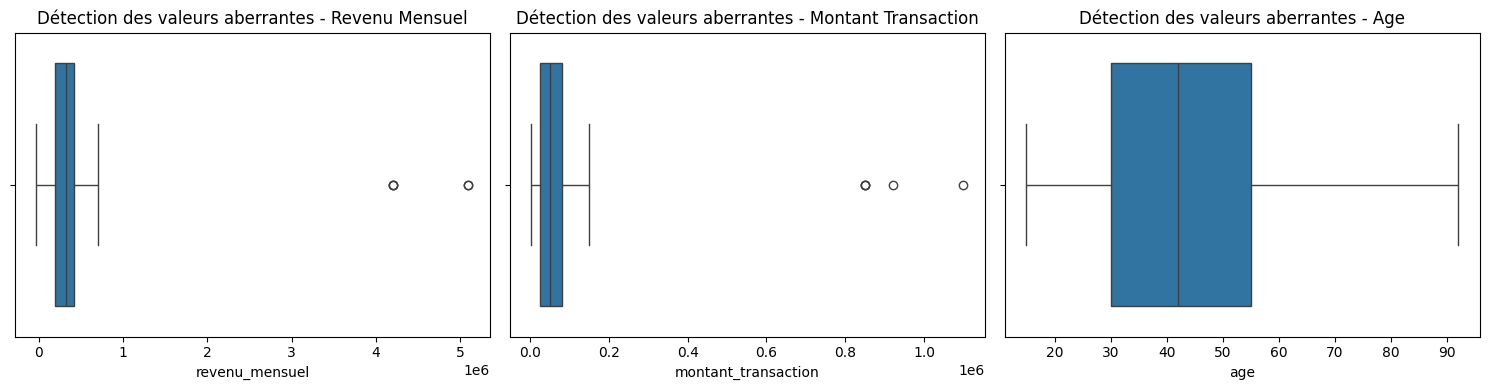

In [86]:
# Détection visuelle par boxplot pour les 3 variables
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.boxplot(x=df['revenu_mensuel'])
plt.title('Détection des valeurs aberrantes - Revenu Mensuel')

plt.subplot(1, 3, 2)
sns.boxplot(x=df['montant_transaction'])
plt.title('Détection des valeurs aberrantes - Montant Transaction')

plt.subplot(1, 3, 3)
sns.boxplot(x=df['age'])
plt.title('Détection des valeurs aberrantes - Age')

plt.tight_layout()
plt.show()

### 2.2 - Calcul des seuils IQR et traitement des outliers

In [87]:
# Gestion des valeurs aberrantes - REVENU MENSUEL
Q1_rev = df['revenu_mensuel'].quantile(0.25)
Q2_rev = df['revenu_mensuel'].quantile(0.50)
Q3_rev = df['revenu_mensuel'].quantile(0.75)
IQR_rev = Q3_rev - Q1_rev

Seuil_inferieur_rev = Q1_rev - 1.5 * IQR_rev
Seuil_superieur_rev = Q3_rev + 1.5 * IQR_rev

print('=== REVENU MENSUEL ===')
print(f'Q1={Q1_rev}, Q2={Q2_rev}, Q3={Q3_rev}')
print(f'Seuil inférieur : {Seuil_inferieur_rev}')
print(f'Seuil supérieur : {Seuil_superieur_rev}')
print('Outliers revenu :', df[df['revenu_mensuel'] > Seuil_superieur_rev].shape[0])

# On remplace les valeurs aberrantes par les seuils (méthode winsorisation)
df['revenu_mensuel'] = np.where(df['revenu_mensuel'] > Seuil_superieur_rev, Seuil_superieur_rev, df['revenu_mensuel'])
df['revenu_mensuel'] = np.where(df['revenu_mensuel'] < Seuil_inferieur_rev, Seuil_inferieur_rev, df['revenu_mensuel'])

=== REVENU MENSUEL ===
Q1=193764.5, Q2=320680.0, Q3=415907.5
Seuil inférieur : -139450.0
Seuil supérieur : 749122.0
Outliers revenu : 5


In [88]:
# Gestion des valeurs aberrantes - MONTANT TRANSACTION
Q1_mt = df['montant_transaction'].quantile(0.25)
Q2_mt = df['montant_transaction'].quantile(0.50)
Q3_mt = df['montant_transaction'].quantile(0.75)
IQR_mt = Q3_mt - Q1_mt

Seuil_inferieur_mt = Q1_mt - 1.5 * IQR_mt
Seuil_superieur_mt = Q3_mt + 1.5 * IQR_mt

print('=== MONTANT TRANSACTION ===')
print(f'Q1={Q1_mt}, Q2={Q2_mt}, Q3={Q3_mt}')
print(f'Seuil inférieur : {Seuil_inferieur_mt}')
print(f'Seuil supérieur : {Seuil_superieur_mt}')
print('Outliers montant :', df[df['montant_transaction'] > Seuil_superieur_mt].shape[0])

df['montant_transaction'] = np.where(df['montant_transaction'] > Seuil_superieur_mt, Seuil_superieur_mt, df['montant_transaction'])
df['montant_transaction'] = np.where(df['montant_transaction'] < Seuil_inferieur_mt, Seuil_inferieur_mt, df['montant_transaction'])

=== MONTANT TRANSACTION ===
Q1=24537.0, Q2=51600.0, Q3=81186.0
Seuil inférieur : -60436.5
Seuil supérieur : 166159.5
Outliers montant : 5


In [89]:
# Gestion des valeurs aberrantes - AGE
Q1_age = df['age'].quantile(0.25)
Q2_age = df['age'].quantile(0.50)
Q3_age = df['age'].quantile(0.75)
IQR_age = Q3_age - Q1_age

Seuil_inferieur_age = Q1_age - 1.5 * IQR_age
Seuil_superieur_age = Q3_age + 1.5 * IQR_age

print('=== AGE ===')
print(f'Q1={Q1_age}, Q2={Q2_age}, Q3={Q3_age}')
print(f'Seuil inférieur : {Seuil_inferieur_age}')
print(f'Seuil supérieur : {Seuil_superieur_age}')
print('Outliers age :', df[df['age'] > Seuil_superieur_age].shape[0])

df['age'] = np.where(df['age'] > Seuil_superieur_age, Seuil_superieur_age, df['age'])
df['age'] = np.where(df['age'] < Seuil_inferieur_age, Seuil_inferieur_age, df['age'])

=== AGE ===
Q1=30.0, Q2=42.0, Q3=55.0
Seuil inférieur : -7.5
Seuil supérieur : 92.5
Outliers age : 0


---
## Question 3 : Imputation des Valeurs Manquantes

In [90]:
# Vérification des valeurs manquantes avant imputation
(df.isnull().sum() / n) * 100

,0
client_id,0.000000
age,0.000000
revenu_mensuel,8.910891
score_credit,11.089109
historique_defaut,0.000000
montant_transaction,6.930693
type_compte,5.940594
frequence_mobile_money,0.000000
pays,3.960396
niveau_risque,2.970297


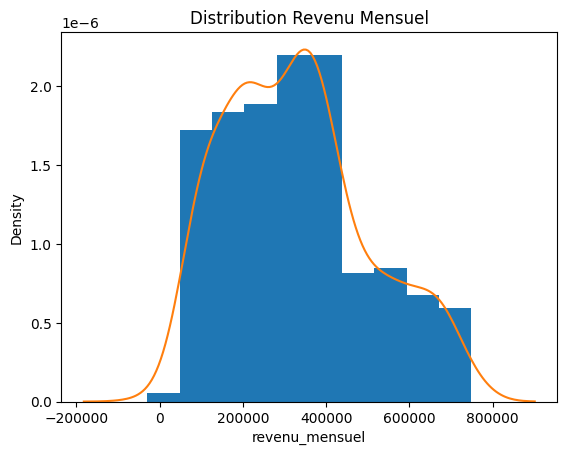

Valeurs manquantes revenu_mensuel : 0


In [91]:
# Imputation de revenu_mensuel par la MEDIANE
# Justification : variable financière souvent asymétrique (revenus élevés = outliers)
# La médiane est plus robuste que la moyenne dans ce cas
plt.hist(df['revenu_mensuel'].dropna(), density=True)
sns.kdeplot(df['revenu_mensuel'].dropna())
plt.title('Distribution Revenu Mensuel')
plt.show()

df['revenu_mensuel'] = df['revenu_mensuel'].fillna(df['revenu_mensuel'].median())
print('Valeurs manquantes revenu_mensuel :', df['revenu_mensuel'].isnull().sum())

In [92]:
# Imputation de score_credit par la MEDIANE
# Justification : le score de crédit peut être asymétrique ; la médiane préserve l'ordre de risque
df['score_credit'] = df['score_credit'].fillna(df['score_credit'].median())
print('Valeurs manquantes score_credit :', df['score_credit'].isnull().sum())

Valeurs manquantes score_credit : 0


In [93]:
# Imputation de montant_transaction par la MEDIANE
# Justification : variable financière asymétrique, la médiane est plus représentative
df['montant_transaction'] = df['montant_transaction'].fillna(df['montant_transaction'].median())
print('Valeurs manquantes montant_transaction :', df['montant_transaction'].isnull().sum())

Valeurs manquantes montant_transaction : 0


In [94]:
# Imputation de retard_paiement par la MEDIANE
# Justification : variable entière représentant le nombre de jours de retard ; médiane évite l'influence des cas extrêmes
df['retard_paiement'] = df['retard_paiement'].fillna(df['retard_paiement'].median())
print('Valeurs manquantes retard_paiement :', df['retard_paiement'].isnull().sum())

Valeurs manquantes retard_paiement : 0


In [95]:
# Imputation de anciennete_client par la MOYENNE
# Justification : distribution plus symétrique, la moyenne est acceptable
df['anciennete_client'] = df['anciennete_client'].fillna(df['anciennete_client'].mean())
print('Valeurs manquantes anciennete_client :', df['anciennete_client'].isnull().sum())

Valeurs manquantes anciennete_client : 0


In [96]:
# Imputation des variables qualitatives par le MODE
# Justification : pour les variables catégorielles, le mode = la valeur la plus fréquente

# type_compte
mode_type_compte = df['type_compte'].mode()[0]
df['type_compte'] = df['type_compte'].fillna(mode_type_compte)
print('type_compte imputation par mode :', mode_type_compte)

# pays
mode_pays = df['pays'].mode()[0]
df['pays'] = df['pays'].fillna(mode_pays)
print('pays imputation par mode :', mode_pays)

# niveau_risque
mode_niveau_risque = df['niveau_risque'].mode()[0]
df['niveau_risque'] = df['niveau_risque'].fillna(mode_niveau_risque)
print('niveau_risque imputation par mode :', mode_niveau_risque)

type_compte imputation par mode : Épargne
pays imputation par mode : Burkina Faso
niveau_risque imputation par mode : Moyen


In [97]:
# Vérification finale : plus aucune valeur manquante
(df.isnull().sum() / n) * 100

,0
client_id,0.0
age,0.0
revenu_mensuel,0.0
score_credit,0.0
historique_defaut,0.0
montant_transaction,0.0
type_compte,0.0
frequence_mobile_money,0.0
pays,0.0
niveau_risque,0.0


---
## Question 4 : Création de 4 Nouvelles Features

### Feature 1 : ratio_dette_revenu
- **Formule** : montant_transaction / revenu_mensuel
- **Justification métier** : mesure le poids des transactions par rapport au revenu. Un ratio élevé signale une dépense disproportionnée et un risque de défaut plus élevé.


In [98]:
# Feature 1 : ratio_dette_revenu = montant_transaction / revenu_mensuel
# On évite la division par zéro avec np.where
df['ratio_dette_revenu'] = np.where(
    df['revenu_mensuel'] > 0,
    df['montant_transaction'] / df['revenu_mensuel'],
    0
)
df['ratio_dette_revenu'].describe()

,ratio_dette_revenu
count,500.000000
mean,0.179524
std,0.089310
min,0.000000
25%,0.114052
50%,0.164902
75%,0.232552
max,0.641927


### Feature 2 : score_risque
- **Formule** : (historique_defaut * 2) + retard_paiement + nombre_prets
- **Justification métier** : combine les signaux de risque passés. L'historique de défaut est pondéré x2 car c'est l'indicateur le plus fort du comportement futur.


In [99]:
# Feature 2 : score_risque_composite
df['score_risque'] = (df['historique_defaut'] * 2) + df['retard_paiement'] + df['nombre_prets']
df['score_risque'].describe()

,score_risque
count,500.000000
mean,4.618000
std,3.285981
min,1.000000
25%,2.000000
50%,4.000000
75%,6.000000
max,17.000000


### Feature 3 : revenu_par_annee_anciennete
- **Formule** : revenu_mensuel / (anciennete_client + 1)
- **Justification métier** : mesure la capacité financière en tenant compte de l'expérience avec la plateforme. Un client anciennement fidèle avec un bon revenu est moins risqué.


In [100]:
# Feature 3 : revenu_par_annee_anciennete
# On ajoute 1 pour éviter la division par zéro
df['revenu_par_annee_anciennete'] = df['revenu_mensuel'] / (df['anciennete_client'] + 1)
df['revenu_par_annee_anciennete'].describe()

,revenu_par_annee_anciennete
count,500.000000
mean,13269.657664
std,13911.900606
min,-600.000000
25%,5933.393697
50%,8732.031250
75%,14587.203977
max,160340.000000


### Feature 4 : intensite_mobile_money
- **Formule** : frequence_mobile_money / (anciennete_client + 1)
- **Justification métier** : dans le contexte africain, l'utilisation intense du Mobile Money par rapport à l'ancienneté reflète l'engagement digital. Un client actif digitalement tend à avoir un meilleur suivi de ses finances.
- **Type** : float (quantitative continue)

In [101]:
# Feature 4 : intensite_mobile_money
df['intensite_mobile_money'] = df['frequence_mobile_money'] / (df['anciennete_client'] + 1)
df['intensite_mobile_money'].describe()

,intensite_mobile_money
count,500.000000
mean,0.943465
std,1.605513
min,0.016807
25%,0.106953
50%,0.295833
75%,1.000000
max,14.000000


In [102]:
# Vérification des 4 nouvelles features
df[['ratio_dette_revenu', 'score_risque', 'revenu_par_annee_anciennete', 'intensite_mobile_money']].head()

,ratio_dette_revenu,score_risque,revenu_par_annee_anciennete,intensite_mobile_money
0,0.085579,12.0,4643.461538,1.692308
1,0.115471,7.0,22742.600000,2.000000
2,0.120577,2.0,26841.000000,4.200000
3,0.345162,2.0,3179.215517,0.051724
4,0.148074,3.0,11899.805556,0.194444


---
## Question 5 : Encodage des Variables Catégorielles

### 5.1 - Variable `type_compte` → OneHot Encoding
**Justification** : 3 modalités sans ordre naturel (Épargne, Courant, Mobile Money). On utilise le OneHot Encoding car aucune modalité n'est supérieure à une autre.

In [103]:
print(df['type_compte'].unique())

# Création de variables : une colonne par modalité
from sklearn.preprocessing import OneHotEncoder
Onhot = OneHotEncoder(sparse_output=False)
resultat_type = Onhot.fit_transform(df[['type_compte']])
df_type_compte = pd.DataFrame(resultat_type, columns=df['type_compte'].unique(), index=df.index)

df = pd.concat([df, df_type_compte], axis=1)
# Suppression de la colonne originale
df = df.drop(['type_compte'], axis=1)

df.head()

['Mobile Money' 'Courant' 'Épargne']


,client_id,age,revenu_mensuel,score_credit,historique_defaut,montant_transaction,frequence_mobile_money,pays,niveau_risque,retard_paiement,nombre_prets,anciennete_client,defaut_paiement,ratio_dette_revenu,score_risque,revenu_par_annee_anciennete,intensite_mobile_money,Mobile Money,Courant,Épargne
0,C0272,50.0,60365.0,437.0,1,5166.0,22,Togo,Très Élevé,1.0,9,12.0,True,0.085579,12.0,4643.461538,1.692308,0.0,1.0,0.0
1,C0207,27.0,227426.0,525.0,2,26261.0,20,Côte d'Ivoire,Élevé,0.0,3,9.0,True,0.115471,7.0,22742.600000,2.000000,1.0,0.0,0.0
2,C0424,33.0,134205.0,478.0,0,16182.0,21,Sénégal,Élevé,0.0,2,4.0,True,0.120577,2.0,26841.000000,4.200000,0.0,0.0,1.0
3,C0342,19.0,368789.0,734.0,0,127292.0,6,Burkina Faso,Faible,0.0,2,115.0,False,0.345162,2.0,3179.215517,0.051724,0.0,1.0,0.0
4,C0001,58.0,428393.0,737.0,0,63434.0,7,Burkina Faso,Faible,0.0,3,35.0,False,0.148074,3.0,11899.805556,0.194444,1.0,0.0,0.0


### 5.2 - Variable `pays` → OneHot Encoding
**Justification** : 7 pays sans ordre naturel entre eux. On utilise le OneHot Encoding pour éviter qu'un encodage numérique laisse croire à une relation d'ordre entre pays.

In [104]:
print(df['pays'].unique())

# On utilise pd.get_dummies qui est plus simple pour les variables nominales
df_pays = pd.get_dummies(df['pays'], prefix='pays')
df = pd.concat([df, df_pays], axis=1)
# Suppression de la colonne originale
df = df.drop(['pays'], axis=1)

df.head()

['Togo' "Côte d'Ivoire" 'Sénégal' 'Burkina Faso' 'Guinée' 'Mali' 'Ghana']


,client_id,age,revenu_mensuel,score_credit,historique_defaut,montant_transaction,frequence_mobile_money,niveau_risque,retard_paiement,nombre_prets,...,Mobile Money,Courant,Épargne,pays_Burkina Faso,pays_Côte d'Ivoire,pays_Ghana,pays_Guinée,pays_Mali,pays_Sénégal,pays_Togo
0,C0272,50.0,60365.0,437.0,1,5166.0,22,Très Élevé,1.0,9,...,0.0,1.0,0.0,False,False,False,False,False,False,True
1,C0207,27.0,227426.0,525.0,2,26261.0,20,Élevé,0.0,3,...,1.0,0.0,0.0,False,True,False,False,False,False,False
2,C0424,33.0,134205.0,478.0,0,16182.0,21,Élevé,0.0,2,...,0.0,0.0,1.0,False,False,False,False,False,True,False
3,C0342,19.0,368789.0,734.0,0,127292.0,6,Faible,0.0,2,...,0.0,1.0,0.0,True,False,False,False,False,False,False
4,C0001,58.0,428393.0,737.0,0,63434.0,7,Faible,0.0,3,...,1.0,0.0,0.0,True,False,False,False,False,False,False


### 5.3 - Variable `niveau_risque` → Label Encoding ordonné
**Justification** : 4 modalités avec un ordre logique clair : Faible < Moyen < Élevé < Très Élevé. On utilise le Label Encoding (encodage ordinal) pour conserver cet ordre naturel, car plus le risque est élevé, plus le défaut est probable.

In [105]:
print(df['niveau_risque'].unique())

# Encodage ordinal manuel pour respecter l'ordre Faible < Moyen < Élevé < Très Élevé
ordre_risque = {'Faible': 0, 'Moyen': 1, 'Élevé': 2, 'Très Élevé': 3}
df['niveau_risque'] = df['niveau_risque'].map(ordre_risque)
df['niveau_risque'] = df['niveau_risque'].astype('category')

print(df['niveau_risque'].unique())
df.dtypes

['Très Élevé' 'Élevé' 'Faible' 'Moyen']
[3, 2, 0, 1]
Categories (4, int64): [0, 1, 2, 3]


,0
client_id,category
age,float64
revenu_mensuel,float64
score_credit,float64
historique_defaut,int64
montant_transaction,float64
frequence_mobile_money,int64
niveau_risque,category
retard_paiement,float64
nombre_prets,int64


## Vérification finale du dataset prétraité

In [106]:
# Vérification : valeur manquante
df.isnull().sum()

,0
client_id,0
age,0
revenu_mensuel,0
score_credit,0
historique_defaut,0
montant_transaction,0
frequence_mobile_money,0
niveau_risque,0
retard_paiement,0
nombre_prets,0


In [107]:
# Taille finale du dataset
print('Taille finale du dataset :', df.shape)
df.head()

Taille finale du dataset : (500, 26)


,client_id,age,revenu_mensuel,score_credit,historique_defaut,montant_transaction,frequence_mobile_money,niveau_risque,retard_paiement,nombre_prets,...,Mobile Money,Courant,Épargne,pays_Burkina Faso,pays_Côte d'Ivoire,pays_Ghana,pays_Guinée,pays_Mali,pays_Sénégal,pays_Togo
0,C0272,50.0,60365.0,437.0,1,5166.0,22,3,1.0,9,...,0.0,1.0,0.0,False,False,False,False,False,False,True
1,C0207,27.0,227426.0,525.0,2,26261.0,20,2,0.0,3,...,1.0,0.0,0.0,False,True,False,False,False,False,False
2,C0424,33.0,134205.0,478.0,0,16182.0,21,2,0.0,2,...,0.0,0.0,1.0,False,False,False,False,False,True,False
3,C0342,19.0,368789.0,734.0,0,127292.0,6,0,0.0,2,...,0.0,1.0,0.0,True,False,False,False,False,False,False
4,C0001,58.0,428393.0,737.0,0,63434.0,7,0,0.0,3,...,1.0,0.0,0.0,True,False,False,False,False,False,False


In [108]:
# Enregistrement du dataset nettoyé
df.to_csv('fintech4africa_dataset_nettoye.csv', index=False)